# QCNNClassifier demonstration on binary MNIST

This notebook presents the `QCNNClassifier` class model to use for vision classification tasks. "QCNN" stands for Quantum Convolutional Neural Network which is mostly used to process images. The architecture of this model is based upon the architecture proposed by [Monbroussou et al. (2025)](https://arxiv.org/abs/2504.20989).

For this demonstration, we will use the `QCNNClassifier` on MNIST of size 8x8 for binary classification between digits 0 and 1. 

## 0. Imports

In [1]:
import matplotlib.pyplot as plt
import merlin
import numpy as np
import perceval
import torch

from merlin.measurement import MeasurementStrategy
from merlin.models import QCNNClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# 1. Dataset

Fetch the 8x8 MNIST dataset from sklearn and select labels.

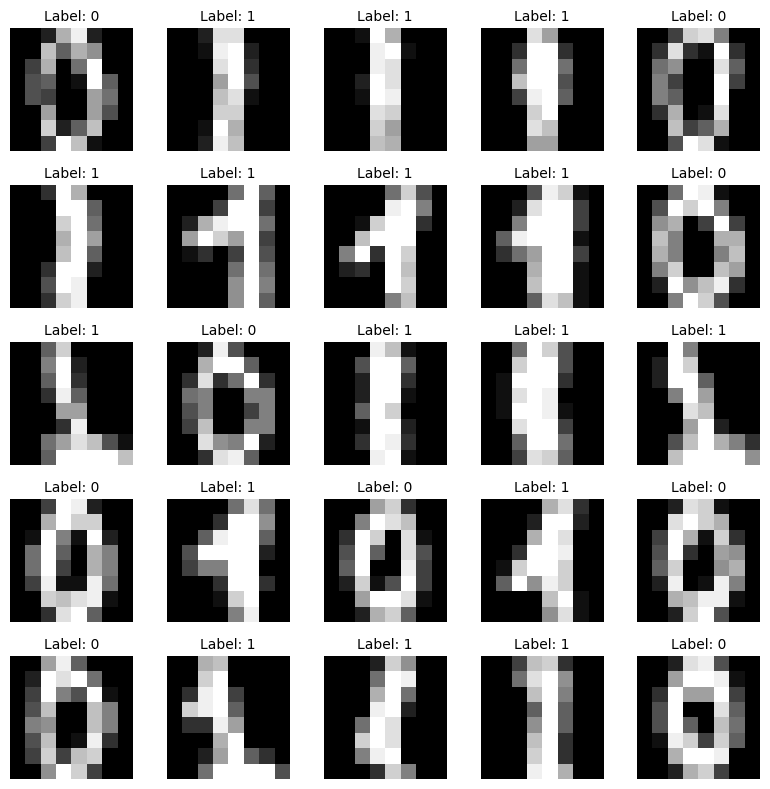

In [25]:
def get_mnist(random_state, class_list=(0, 1)):
    """
    Get MNIST dataset reduced to certain labels.

    :param random_state
    :param class_list: List of labels to keep

    :return: x_train, x_test, y_train, y_test
    """
    mnist_x, mnist_y = load_digits(return_X_y=True)

    # Keep only selected classes
    mask = np.isin(mnist_y, class_list)
    mnist_x = mnist_x[mask]
    mnist_y = mnist_y[mask]

    # Train/test split
    mnist_x_train, mnist_x_test, mnist_y_train, mnist_y_test = train_test_split(
        mnist_x, mnist_y, test_size=200, random_state=random_state
    )
    # Since there are only 360 data points in this specific dataset with labels = 0 or 1, that implies that we will have 160 training points.

    # Reshape to 8×8 images
    mnist_x_train = mnist_x_train.reshape(-1, 8, 8)
    mnist_x_test = mnist_x_test.reshape(-1, 8, 8)

    return mnist_x_train, mnist_x_test, mnist_y_train, mnist_y_test


# Visualize images from our training data
x_train, x_test, y_train, y_test = get_mnist(42)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

Convert the training data to `torch.Tensor` (of shape \[batch_size, 1, input_shape[0], input_shape[1]\]) and to `torch.utils.data.DataLoader`.

In [12]:
def convert_dataset_to_tensor(x_train, x_test, y_train, y_test):
    x_train = torch.tensor(x_train, dtype=torch.float32)
    x_train = x_train.unsqueeze(1)
    x_test = torch.tensor(x_test, dtype=torch.float32)
    x_test = x_test.unsqueeze(1)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)
    return x_train, x_test, y_train, y_test


def convert_tensor_to_loader(x_train, y_train, batch_size=30):
    train_dataset = torch.utils.data.TensorDataset(x_train, y_train)
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )
    return train_loader

## 2. Model definition

The `QCNNClassifier` class takes three initialization parameters: `input_shape`, `num_classes` and `stages`. In this context, we have that `input_shape` = (8, 8) and `num_classes` = 2. We will not specify the `stages` parameter, so the default architecture will be used: a `QConv(2, 2)` layer followed by a `QPool(2)` layer, a `QDense()` layer and a Readout layer. Note that if you specify the `stages` directly, the `QDense` layer has to only appear as the last stage and that the Readout layer is always automatically added to the architecture to map from the output size of the `QDense` layer to the number of classes.

In [13]:
qcnn = QCNNClassifier(input_shape=(8, 8), num_classes=2)

Before going straight to the classification task, let's analyze the structure of the default `QCNNClassifier`.

In [14]:
stages = qcnn.resolved_stages

for stage in stages:
    print(stage)

QConv(kernel_size=2, stride=2)
QPool(kernel_size=2)
QDense()


In [15]:
layers = qcnn.layers

for index, (name, layer) in enumerate(layers.named_children()):
    print(f"Layer {index}: {name} of type {type(layer)}")

Layer 0: QConv_1 of type <class 'merlin.algorithms.layer.QuantumLayer'>
Layer 1: QPool_1 of type <class 'merlin.algorithms.layer.QuantumLayer'>
Layer 2: QDense of type <class 'merlin.algorithms.layer.QuantumLayer'>
Layer 3: Readout of type <class 'torch.nn.modules.linear.Linear'>


We can access to QuantumLayer for each stage to visualize their photonic circuit using `perceval`.

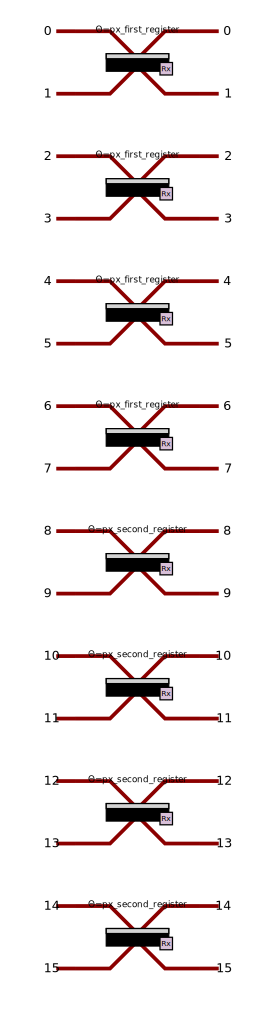

In [16]:
conv_layer = layers[0]
pool_layer = layers[1]
dense_layer = layers[2]
linear_layer = layers[3]

conv_circuit = conv_layer.circuit
perceval.pdisplay(conv_circuit)

This circuit is expected because the number of modes, for this architecture, equals the sum of the input dimensions (8 + 8 = 16) and the convolutions of `kernel_size` = 2 and `stride` = 2 are expected to be non-overlapping beam splitters.

The pooling layer does not utilize circuit components so its circuit visualization would be empty. Instead, we can verify that its `measurement_stategy` is that of partial measurement.

In [17]:
pool_m_strat = pool_layer.measurement_strategy
assert isinstance(pool_m_strat, MeasurementStrategy)
print(f"Pooling layer has measurement type: {pool_m_strat.type}")
print(f"Measured modes: {pool_m_strat.measured_modes}")
print(f"Computation space: {pool_m_strat.computation_space}")

Pooling layer has measurement type: MeasurementKind.PARTIAL
Measured modes: (0, 2, 4, 6, 8, 10, 12, 14)
Computation space: ComputationSpace.FOCK


The measured modes we see there are what we expect with a pooling layer of `stride` = 2, since the pooling window measures the upper mode present before moving downward by `stride` modes.

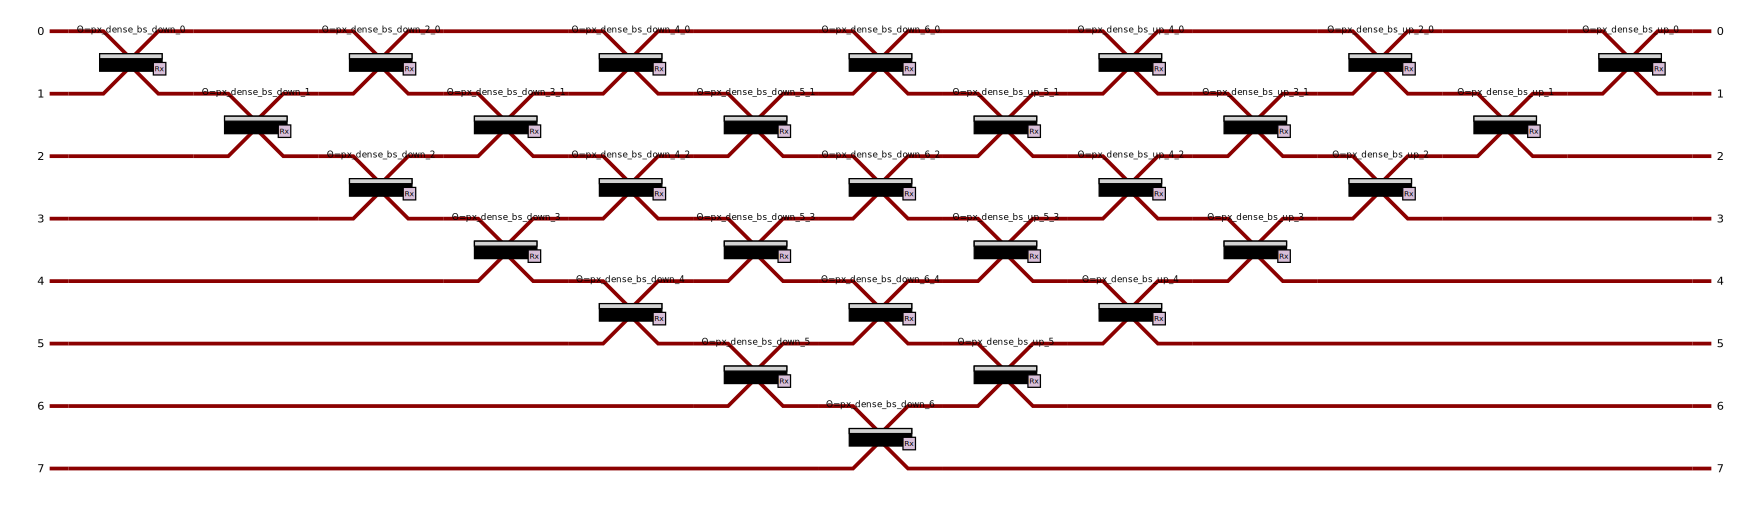

In [18]:
dense_circuit = dense_layer.circuit
perceval.pdisplay(dense_circuit)

This circuit is expected because the architecture started off with 16 modes, but 8 were measured. Thus, 8 modes are left for the dense layer. Then, this triangular beam splitter mesh pattern is the one used for the `QDense` stage.

We can finally look at the Readout layer; the Linear layer.

In [19]:
in_linear_layer = linear_layer.in_features
out_linear_layer = linear_layer.out_features

out_dense = dense_layer.output_size

print(f"Output size from the QDense stage: {out_dense}")
print(f"Into the Linear layer with input size: {in_linear_layer}")
print(f"Linear layer maps to output size: {out_linear_layer}")
print(f"Which corresponds to the number of classes: {qcnn.num_classes}")

Output size from the QDense stage: 36
Into the Linear layer with input size: 36
Linear layer maps to output size: 2
Which corresponds to the number of classes: 2


The output size of 36 is expected from the `QDense` stage since there are 2 photons present in 8 modes which implies $\binom{8+2-1}{2} = 36$ different combinations. Moreover, the linear layer maps from this dimension to the number of classes to obtain logits (raw score for each class).

Lastly, let's look at the distribution of trainable parameters.

In [20]:
num_params = sum(p.numel() for p in qcnn.parameters() if p.requires_grad)
print(f"QCNNClassifier has {num_params} trainable parameters")

for index, (name, layer) in enumerate(layers.named_children()):
    num_layer_params = sum(p.numel() for p in layer.parameters() if p.requires_grad)
    print(f"Layer {index}: {name} has {num_layer_params} trainable parameters")

QCNNClassifier has 104 trainable parameters
Layer 0: QConv_1 has 2 trainable parameters
Layer 1: QPool_1 has 0 trainable parameters
Layer 2: QDense has 28 trainable parameters
Layer 3: Readout has 74 trainable parameters


# 3. Training of the model

In [21]:
def train_model(model, train_loader, x_train, x_test, y_train, y_test):
    """Train a single model and return training history"""
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1, weight_decay=0.001)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
    loss_fn = torch.nn.CrossEntropyLoss()

    loss_history = []
    train_acc_history = []
    test_acc_history = []

    # Initial accuracy
    with torch.no_grad():
        logits_train = model(x_train)
        pred_train = torch.argmax(logits_train, dim=1)
        train_acc = (pred_train == y_train).float().mean().item()

        logits_test = model(x_test)
        pred_test = torch.argmax(logits_test, dim=1)
        test_acc = (pred_test == y_test).float().mean().item()

        train_acc_history.append(train_acc)
        test_acc_history.append(test_acc)

    # Training loop
    for _ in tqdm(range(20), desc="Training epochs"):
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = loss_fn(output, labels)
            loss.backward()
            optimizer.step()
            loss_history.append(loss.item())

        # Evaluate accuracy
        with torch.no_grad():
            logits_train = model(x_train)
            pred_train = torch.argmax(logits_train, dim=1)
            train_acc = (pred_train == y_train).float().mean().item()

            logits_test = model(x_test)
            pred_test = torch.argmax(logits_test, dim=1)
            test_acc = (pred_test == y_test).float().mean().item()

            train_acc_history.append(train_acc)
            test_acc_history.append(test_acc)
        scheduler.step()
        
    return {
        "loss_history": loss_history,
        "train_acc_history": train_acc_history,
        "test_acc_history": test_acc_history,
        "final_train_acc": train_acc,
        "final_test_acc": test_acc,
    }

Conduct training of the `QCNNClassifier` across multiple random seeds.

In [22]:
random_states = [42, 123, 456, 789, 999]
all_results = {}

for i, random_state in enumerate(random_states):
    print(f"Starting experiment {i + 1}/5")
    x_train, x_test, y_train, y_test = get_mnist(random_state=random_state)
    x_train, x_test, y_train, y_test = convert_dataset_to_tensor(
        x_train, x_test, y_train, y_test
    )
    # Ensure good shape of data
    assert x_train.shape == (x_train.shape[0], 1, 8, 8), print(f"{x_train.shape}")
    assert x_test.shape == (x_test.shape[0], 1, 8, 8), print(f"{x_test.shape}")
    
    train_loader = convert_tensor_to_loader(x_train, y_train)
    dims = (8, 8)

    qcnn = QCNNClassifier((8, 8), 2)

    results = train_model(qcnn, train_loader, x_train, x_test, y_train, y_test)
    print(
        f"MNIST - Final train: {results['final_train_acc']:.4f}, test: {results['final_test_acc']:.4f}"
    )
    print(f"Experiment {i + 1}/5 completed")
    all_results[f"run_{i}"] = results

Starting experiment 1/5


Training epochs: 100%|██████████| 20/20 [00:31<00:00,  1.59s/it]


MNIST - Final train: 1.0000, test: 0.9950
Experiment 1/5 completed
Starting experiment 2/5


Training epochs: 100%|██████████| 20/20 [00:33<00:00,  1.69s/it]


MNIST - Final train: 1.0000, test: 0.9900
Experiment 2/5 completed
Starting experiment 3/5


...

MNIST - Final train: 1.0000, test: 0.9850
Experiment 3/5 completed
Starting experiment 4/5


Training epochs: 100%|██████████| 20/20 [00:32<00:00,  1.64s/it]


MNIST - Final train: 0.9875, test: 1.0000
Experiment 4/5 completed
Starting experiment 5/5


Training epochs: 100%|██████████| 20/20 [00:33<00:00,  1.67s/it]

MNIST - Final train: 1.0000, test: 1.0000
Experiment 5/5 completed


## 4. Results

Visualize training metrics and recap final results.

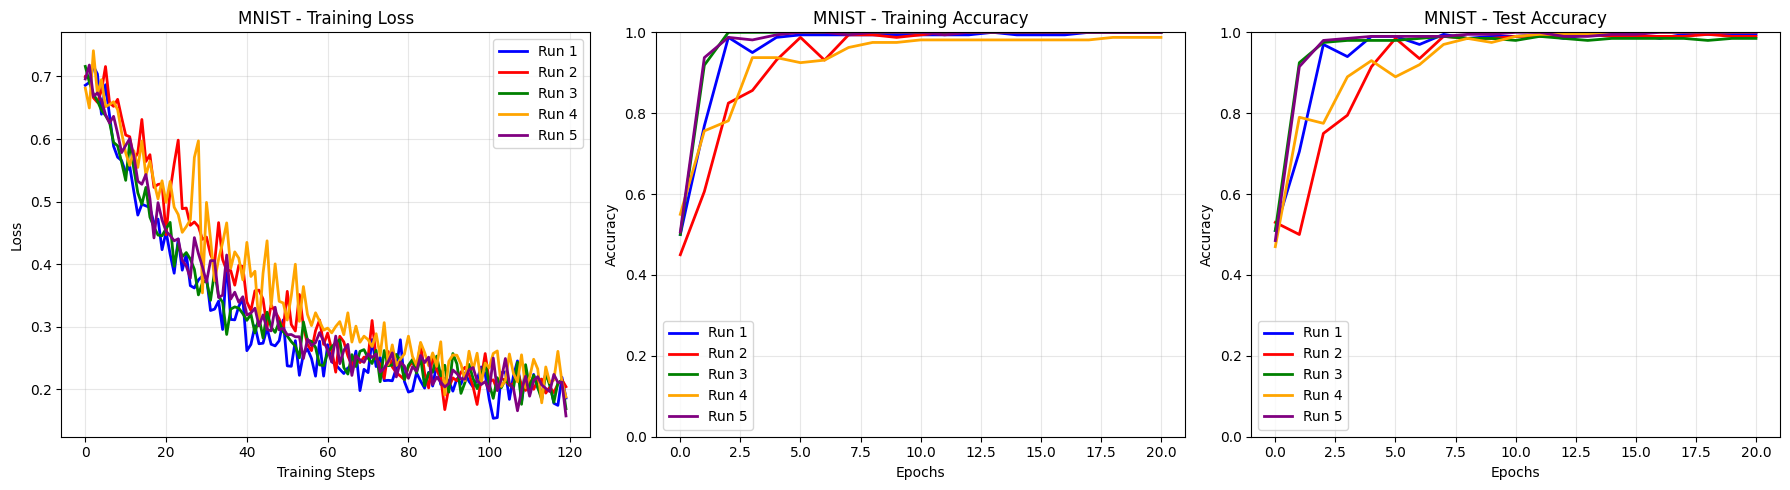


Summary Results:
Binary MNIST 0 vs 1:
  Train Accuracy: 0.998 ± 0.005
  Test Accuracy:  0.994 ± 0.006


In [23]:
# Save summary statistics
summary = {}
num_runs = len(all_results)
train_accs = [all_results[f"run_{i}"]["final_train_acc"] for i in range(num_runs)]
test_accs = [all_results[f"run_{i}"]["final_test_acc"] for i in range(num_runs)]

summary = {
    "train_acc_mean": np.mean(train_accs),
    "train_acc_std": np.std(train_accs),
    "test_acc_mean": np.mean(test_accs),
    "test_acc_std": np.std(test_accs),
    "train_accs": train_accs,
    "test_accs": test_accs,
}

# Create training plots for each dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["blue", "red", "green", "orange", "purple"]

# Plot loss history for this dataset
ax_loss = axes[0]
for run_idx in range(num_runs):
    loss_history = all_results[f"run_{run_idx}"]["loss_history"]
    ax_loss.plot(
        loss_history,
        color=colors[run_idx],
        alpha=1,
        linewidth=2,
        label=f"Run {run_idx + 1}",
    )
ax_loss.set_title("MNIST - Training Loss")
ax_loss.set_xlabel("Training Steps")
ax_loss.set_ylabel("Loss")
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

# Plot train accuracy for this dataset
ax_train = axes[1]
for run_idx in range(num_runs):
    train_acc_history = all_results[f"run_{run_idx}"]["train_acc_history"]
    epochs = range(len(train_acc_history))
    ax_train.plot(
        epochs,
        train_acc_history,
        color=colors[run_idx],
        alpha=1,
        linewidth=2,
        label=f"Run {run_idx + 1}",
    )
ax_train.set_title("MNIST - Training Accuracy")
ax_train.set_xlabel("Epochs")
ax_train.set_ylabel("Accuracy")
ax_train.legend()
ax_train.grid(True, alpha=0.3)
ax_train.set_ylim(0, 1)

# Plot test accuracy for this dataset
ax_test = axes[2]
for run_idx in range(num_runs):
    test_acc_history = all_results[f"run_{run_idx}"]["test_acc_history"]
    epochs = range(len(test_acc_history))
    ax_test.plot(
        epochs,
        test_acc_history,
        color=colors[run_idx],
        alpha=1,
        linewidth=2,
        label=f"Run {run_idx + 1}",
    )
ax_test.set_title("MNIST - Test Accuracy")
ax_test.set_xlabel("Epochs")
ax_test.set_ylabel("Accuracy")
ax_test.legend()
ax_test.grid(True, alpha=0.3)
ax_test.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Print summary
print("\nSummary Results:")
print("=" * 50)
print("Binary MNIST 0 vs 1:")
print(
    f"  Train Accuracy: {summary['train_acc_mean']:.3f} ± {summary['train_acc_std']:.3f}"
)
print(
    f"  Test Accuracy:  {summary['test_acc_mean']:.3f} ± {summary['test_acc_std']:.3f}"
)

These results are what we expect from this architecture on this specific dataset, as they are what we have previously reached using a density matrix approach for computation.